<center>

# Rapport Projet de Deep Learning
## Sujet : Diagnostic des maladies neurologiques rares à partir des images IRM
#### Réalisé par ASSIDAH Asma, MASSON Louis, ZIRN Léna
#### Master 1 Imagerie Médicale
#### Avril 2026

</center>

# Introduction

Les maladies neurologiques sont définies par un dysfonctionnement du système nerveux central ou périphérique, ce qui implique que ce sont des affections qui touchent principalement le cerveau et les nerfs crâniens ou périphériques. C’est pour cette raison que l’on utilise l’Imagerie par Résonance Magnétique (IRM) pour les identifier. En effet, l’IRM constitue un excellent outil pour visualiser le cerveau qui est composé majoritairement de tissus mous (substance blanche, grise et liquide céphalorachidien) que l’IRM permet de contraster pour y voir des détails très fins. De plus, c’est une technique d’imagerie non-invasive qui est alors plus adaptée aux maladies chroniques. Cependant, il existe plus de 600 types de maladies neurologiques et leur diagnostic peut ainsi être complexe. On considère une maladie rare lorsqu’elle affecte moins d’une personne sur 2000. Dans notre cas, on étudiera le diagnostic des maladies suivantes : la dystrophie musculaire congénitale type Fukuyama, la maladie d'Hallervorden-Spatz, la maladie de Moya Moya, la pachygyrie avec hypoplasie cérébelleuse et enfin le syndrome de Walker-Warburg.

L’objectif de ce projet est de diagnostiquer ces maladies à l’aide d’un algorithme d’apprentissage automatique. Tout d’abord, en ce qui concerne nos données, il est important d’en préciser la nature. En effet, les données fournies sont des images cérébrales d’IRM-T1 de type JPEG et RGB (même si visuellement noires et blanches) et de dimensions 256x256 ou 512x512. On rappelle que notre but est d’automatiser le diagnostic. Pour cela, les images ont déjà été classées par types de maladies auxquelles elles appartiennent. D’autre part, nous avons à notre disposition une base de test, qui comporte 60 images pour chaque classe, soit un total de 300 images, puis une base de training avec 280 images par classe, soit 1400 images au total et enfin, une base de validation de 60 images par classe également. Ces bases de données vont alors nous permettre d’entraîner un modèle à l’aide des données de training et de validation ainsi que d’en évaluer les performances avec la base de test.
    
En ce qui concerne le modèle développé, l’entraînement sera réalisé à travers des réseaux de neurones convolutifs car, compte tenu de la quantité de données que nous possédons, l’apprentissage profond (Deep Learning) mais plus particulièrement les CNN (Convolutional Neural Networks) constituent un outil bien plus adapté à notre cas en raison de la nature de nos données (images). Tout au long de ce projet, nous avons mis en œuvre et testé différentes architectures dans le but d’obtenir une précision de 99%.

Dans un premier temps, nous passerons en revue les différentes architectures testées ainsi que leurs performances associées. Ensuite, nous étudierons les spécificités d’un réseau de neurones pré-entraîné, le VGG16. En effet, nous analyserons son fonctionnement puis nous en déduirons une architecture adaptée à nos besoins à partir de transfer learning et plus particulièrement par fine tuning. Par la suite, nous visualiserons les filtres entraînés pour en extraire les caractéristiques extraites par le réseau et ainsi comprendre davantage le fonctionnement du modèle interne. Finalement, nous terminerons avec une évaluation des performances de notre modèle avec à l’appui des exemples d’utilisation de l’algorithme à travers une API.


# 1. Structure du programme

## 1.1. Réseaux de neurones convolutifs


Comme précisé précédemment, nos données sont des images de type JPEG, stockées dans des dossiers selon leur classe. On rappelle également qu’ici, on cherche à déterminer une première approche de notre modèle à l’aide d’un réseau de neurones convolutif.
D'autre part, pour développer notre réseau, il est important de savoir exactement ce sur quoi on travaille. En effet, un CNN est un type de réseau de neurones convolutifs qui utilise la convolution dans au moins une couche. Comme tout réseaux de neurones, un CNN est composé d’une couche d’entrée, de couches cachées ainsi que d’une couche de sortie. Cependant, le CNN est plus particulier car, contrairement aux MLP (Perceptron Multi-Couches), un neurone d’une couche n’est pas connecté à tous les neurones d’une autre couche. En effet, le principe même d’un CNN est l’application de noyaux de convolution (filtres) à chaque entrée d’une couche pour l’extraction automatique de caractéristiques. C’est ce qu’on appelle des couches de convolution. Ainsi, la petite taille du noyau de convolution limite le nombre de connexions entre neurones des couches successives. Cela permet de réduire à la fois le nombre de paramètres du modèle et le coût de calcul.

Par ailleurs, une couche convolutive est composée de 3 étapes :
-convolutions réalisées en parallèle pour produire un ensemble d’activations linéaires
-couches d’activation avec fonctions d’activation : souvent Relu
-couches de Pooling (sous-échantillonnage) : réduit la taille de l’image et garde l’essentiel (MaxPooling)

Comme on peut le voir ci-dessous, en général, les premières couches correspondent aux convolutions, puis, comme les couches denses (fully-connected) ont besoin de données d’entrée à une dimension, on effectue une opération de flattening entre la couche convolutive et la couche dense pour mettre à plat nos données. De cette manière, les couches denses récupèrent des vecteurs de données qui pourront par la suite être utilisés pour la classification finale.


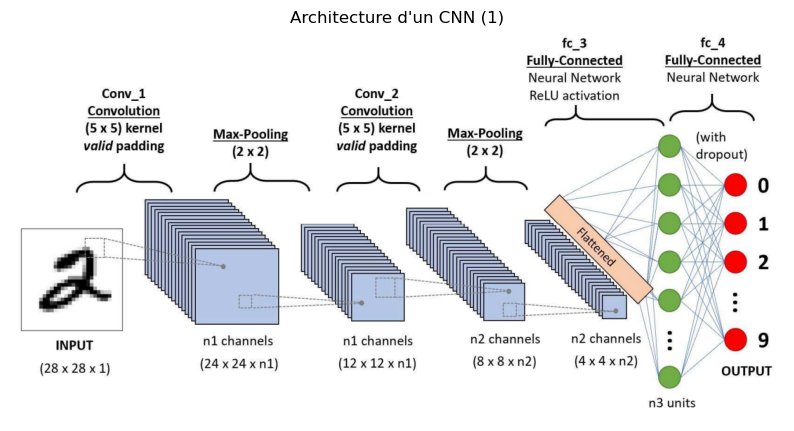

In [30]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
from tensorflow.keras import datasets, layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator
import pandas as pd
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import model_from_json
import cv2
from PIL import Image, ImageOps
from sklearn.metrics import confusion_matrix, classification_report
import streamlit as st
import matplotlib.image as mpimg

es = EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=20)

checkpoint_filepath = '/tmp/ckpt/checkpoint.model.keras'
cb = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

img = mpimg.imread('CNNcours.png')

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Architecture d'un CNN (1)", fontsize=12)
plt.axis('off')
plt.show()

## 1.2. Architecture des premiers modèles

Pour concevoir le modèle qui nous permettra de classifier une image en fonction de la maladie qu’elle représente, nous avons tout d’abord mis en œuvre divers réseaux de neurones avec plusieurs architectures afin d’essayer de déterminer un modèle qui fournit les meilleures performances. Le code se divise alors en 5 étapes que l’on va détailler ci-dessous.


Tout d’abord, la première étape consiste à préparer les images dans le but d’entraîner le modèle à partir de ces mêmes images auxquelles on aura appliqué un pré-traitement. Pour cela, on utilise le module ImageDataGenerator qui permet d’appliquer des modifications aux images afin d’enrichir la base de données. Dans notre cas, nos images sont de type RGB où chaque canal appartient à l’intervalle [0,255]. Ainsi, afin de faciliter l’apprentissage du modèle, on normalise nos images pour les ramener à une plage [0,1] à l’aide de la commande rescale=1./255.

In [32]:
# ==================== Generator ==================== #


train_datagen = ImageDataGenerator(
        #rotation_range=40,
        #width_shift_range=0.2,
        #weight_shift_range=0.2,
        rescale=1./255, # normalisation des valeurs : 0-255
        #shear_range=0.2,
        #zoom_range=0.2,
        #horizontal_flip=True,
        #fill_mode='nearest'
        )

valid_datagen = ImageDataGenerator(
        #rotation_range=40,
        #width_shift_range=0.2,
        #weight_shift_range=0.2,
        rescale=1./255, # normalisation des valeurs : 0-255
        #shear_range=0.2,
        #zoom_range=0.2,
        #horizontal_flip=True,
        #fill_mode='nearest'
        )

test_datagen = ImageDataGenerator(
        #rotation_range=40,
        #width_shift_range=0.2,
        #weight_shift_range=0.2,
        rescale=1./255, # normalisation des valeurs : 0-255
        #shear_range=0.2,
        #zoom_range=0.2,
        #horizontal_flip=True,
        #fill_mode='nearest'
       )

Par la suite, la deuxième étape permet de générer nos données d’entraînement (train_generator), de validation (valid_generator) et de test (test_generator). Pour cela, on utilise flow_from_directory qui permet alors de charger les images par lots d’apprentissage de 32 (batch_size), puis, de les redimensionner (target_size=(256,256)), de choisir leur nouveau type (color_mode="grayscale"), de choisir le mode de sélection parmi l’ensemble d’images (shuffle=True : choix aléatoire pour éviter que le modèle apprenne un ordre, amélioration de la généralisation) et enfin  d’assurer que le mélange aléatoire sera toujours le même pour une epoch (seed=42).

In [34]:
# ==================== Générateur de Data ==================== #


test_generator = test_datagen.flow_from_directory(
    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/test/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=1,
    class_mode="categorical",
    shuffle=False,
 
)

train_generator = train_datagen.flow_from_directory(
    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/train/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

valid_generator = valid_datagen.flow_from_directory(
    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/val/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

Found 300 images belonging to 5 classes.
Found 1400 images belonging to 5 classes.
Found 300 images belonging to 5 classes.


La troisième étape consiste alors à mettre en forme le CNN en construisant son architecture. Afin d’améliorer les performances du réseau, il est important de comprendre la structure et les paramètres des couches que nous allons utiliser.

#### Convolution2D(filters, kernel_size, padding, input_shape, activation)

Cette couche permet d’appliquer une convolution 2D à la couche qui la précède dans le but de produire un tenseur de valeurs (un tenseur est une structure de données : scalaires,vecteurs, matrices). “filters” permet de choisir le nombre de filtres pour la convolution, “kernel_size” permet de spécifier la taille du noyau de convolution, “padding” indique si la convolution sera réalisée avec ou sans zero-padding. En effet, le zero-padding de l'entrée nous permet de contrôler la largeur du noyau et la taille de la sortie indépendamment. Dans notre cas, on choisira d’effectuer la convolution avec zero-padding (padding=”same”) car on souhaite conserver la taille de l’image en sortie de la couche pour éviter de perdre de l’information spatiale. Par la suite, le paramètre “input_shape” permet de redimensionner les images d’entrée et enfin, “activation” permet d’introduire de la non-linéarité dans le réseau pour qu’il puisse apprendre des données plus complexes. On utilisera alors l’option “relu” (Rectified Linear Unit) qui caractérise l’apprentissage d’un neurone seulement lorsque son activation est positive. C’est une fonction d’activation facile à calculer et qui permet d’éviter le surapprentissage.

#### BatchNormalization()

Le Batch Normalization est une couche qui permet de centrer et réduire les données d’entrée pendant la phase d’apprentissage. Ainsi, on obtient une moyenne nulle et un écart-type de 1 qui induisent une stabilisation de l’apprentissage tout en améliorant sa vitesse. De cette manière, on évite un déséquilibre au niveau des données en les “recadrant”.

#### MaxPooling2D(pool_size, strides)

Le Max Pooling 2D prend la valeur maximale dans un voisinage rectangulaire. En d’autres termes, il garde les caractéristiques importantes tout en réduisant la dimension, de cette manière, le temps de calcul diminue. “pool_size” définit la taille de la fenêtre et “strides” indique le pas de déplacement.

#### Flatten()

La couche de Flattening (ou mise à plat) transforme les données à 2 ou plusieurs dimensions (dans notre cas : 2D) pour qu’elles soient reçues par les couches denses sous la forme d’un vecteur 1D. C’est donc une réduction de dimension.

#### Dense(units, activation)

Cette couche désigne une couche où tous les neurones sont totalement connectés (fully-connected) entre eux pour réaliser la classification (ou régression). De cette manière, toutes les caractéristiques sont combinées afin de réaliser la prédiction finale. “units” correspond au nombre de neurones dans la couche et “activation” désigne le type de fonction d’activation appliquée en sortie des neurones. Dans notre cas, la dernière couche dense permet de faire la classification finale et c’est pour cette raison que la fonction softmax sera utilisée car elle transforme les sorties du réseau en probabilités dont la somme vaut 1, permettant ainsi d’identifier la classe la plus probable.


#### Dropout(rate)

La couche de Dropout consiste à désactiver aléatoirement une fraction des neurones (et leurs connexions) durant l’entraînement. Cela permet d’améliorer la généralisation du modèle en évitant qu’il ne repose trop sur certains neurones. “rate” indique le pourcentage de neurones désactivés à chaque itération. Cela permet aussi de réduire le sur-apprentissage.

#### Compilation

Une fois l’architecture déterminée, il est nécessaire de compiler le modèle afin de le configurer dans le but de guider l’apprentissage. La fonction compile() permet alors de définir la méthode d’optimisation (paramètre “optimizer”) ainsi que la fonction de coût à minimiser (paramètre “loss”) et finalement, elle choisit le critère utilisé pour juger les performances du modèle (paramètre “metrics”). On utilisera l’optimiseur Adam qui ajuste les poids du modèle pour réduire l’erreur, la fonction de perte categorical_crossentropy qui mesure l’écart entre les vraies classes et les prédictions et accuracy comme métrique pour obtenir le pourcentage de bonnes prédictions.


#### Apprentissage du modèle

Pour entraîner le modèle, on utilise le module fit() qui permet de réaliser l’apprentissage avec une base de données labellisée. Ce module prend en compte plusieurs paramètres dont la base de données train_generator mais aussi le “batch_size” qui définit le nombre d’échantillons par gradient, “epochs” qui désigne le nombre de cycles d’entraînement du modèle, “verbose” qui gère l’affichage et permet la visualisation en ce qui concerne la progression du modèle, “validation_data” qui évalue la perte à la fin de chaque epoch à partir de la base de validation et enfin, “callbacks” qui effectue une action régulière. Ici, callbacks va permettre de réaliser un arrêt précoce (EarlyStopping) si le pourcentage de perte ne diminue pas sur un nombre donné d’epochs.

#### Évaluation du modèle

Dans le but de déterminer un modèle qui réponde à nos exigences, il est nécessaire d’évaluer chaque modèle. Nos critères se basent alors sur plusieurs caractéristiques et notamment l’accuracy du modèle appliqué à la base de test mais aussi les valeurs de perte et d’accuracy sur la base d’entraînement et de validation à chaque epoch . De cette manière, on peut en conclure sur l’efficacité du modèle en se basant sur ses performances.


# 2. Conception et tests de plusieurs modèles

Pour concevoir le CNN qui réponde à nos besoins, nous avons procédé à de nombreux essais en modifiant la structure du réseau : nombre de couches de convolution, nombre et taille des filtres, nombre de neurones sur la couche dense, taux de dropout, etc.

Dans cette partie, nous allons présenter seulement deux modèles que nous avons mis en œuvre avant de nous pencher sur les réseaux pré-entraînés qui constitueront notre modèle final.

## 2.1. Plusieurs modèles

### 2.1.a. Premier modèle

Notre premier modèle est composé de deux couches de convolution, suivies d’une couche de flattening et d’une couche dense. La première couche de convolution comprend 20 filtres avec un noyau de taille 3×3, tandis que la seconde en comporte 50, également avec un noyau de taille 3×3. La couche dense finale est constituée de 500 neurones. Un dropout de 50 % a également été appliqué afin de limiter le surapprentissage.


In [35]:
# ==================== Construction du modèle ==================== #


NB_CLASSES = 5;   # Nombre de classes

model = models.Sequential()

# 1e couche convolutive
model.add(layers.Convolution2D(20, (3, 3), padding= 'same',input_shape=(256,256,1), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# 2e couche convolutive
model.add(layers.Convolution2D(50, (3, 3), padding= 'same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(layers.Flatten()) 

# Couche dense
model.add(layers.Dense(500, activation="relu"))
model.add(layers.Dropout(0.5))

# softmax dense classifier
model.add(layers.Dense(NB_CLASSES, activation="softmax"))

# summary du modèle
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_6 (Conv2D)            (None, 256, 256, 20)      200       
_________________________________________________________________
batch_normalization_6 (Batch (None, 256, 256, 20)      80        
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 128, 128, 20)      0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 128, 128, 50)      9050      
_________________________________________________________________
batch_normalization_7 (Batch (None, 128, 128, 50)      200       
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 64, 64, 50)        0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 204800)           

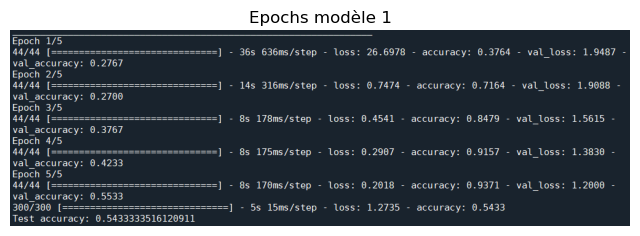

In [36]:
img = mpimg.imread('mod1perf.png')

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Epochs modèle 1", fontsize=12)
plt.axis('off')
plt.show()

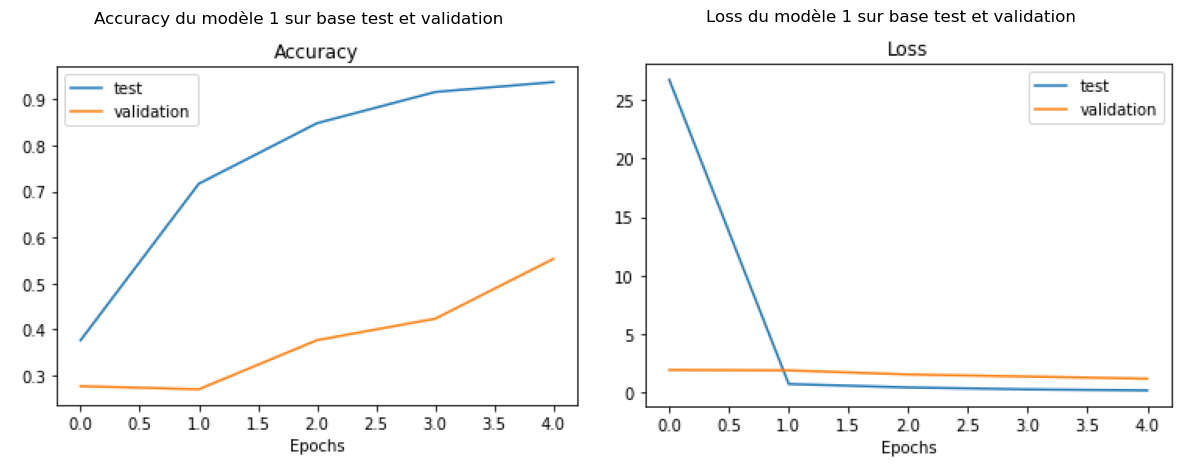

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('mod1courbeacc.png'))
axes[0].set_title('Accuracy du modèle 1 sur base test et validation')
axes[0].axis('off')

axes[1].imshow(mpimg.imread('mod1courbeloss.png'))
axes[1].set_title('Loss du modèle 1 sur base test et validation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

On peut voir le nombre de paramètres que le modèle utilise, ainsi que la taille du tenseur en sortie des couches. On voit alors que le modèle comporte environ 102 millions de paramètres, dont la quasi-totalité est entraînable, ce qui lui confère une grande capacité d’apprentissage mais augmente également le risque de surapprentissage.

En termes de performances, avec 5 epochs, le modèle atteint une accuracy d’environ 54% sur la base de test, une valeur d’accuracy bien loin des 99% que l’on vise. De plus, l’accuracy sur la base d’apprentissage et sur la base de validation est problématique : 94% sur la base de test contre ~30% sur la base de validation. On peut ainsi conclure que le modèle ne généralise pas assez et cela est cohérent avec le nombre de paramètres trouvés précédemment. En effet, avec 102 millions de paramètres, le modèle est puissant certes, mais il apprend trop localement et n’arrive pas à retenir les données globales. Par ailleurs, on peut aussi souligner le faible nombre d’epochs qui empêche le modèle d’apprendre suffisamment car on le stoppe bien trop prématurément.

### 2.1.b. Autres modèles

Les prochains modèles ont donc permis de chercher une généralisation du modèle, tout en réduisant sa complexité et le risque de surapprentissage. Nous avons essayer les modèles suivants:

<table>
  <tr>
    <th>Modèle</th>
    <th>Nb noyaux de conv. (couche 1)</th>
    <th>Nb noyaux de conv. (couche 2)</th>
    <th>Nb noyaux de conv. (couche 3)</th>
      <th>Dropout(dense)</th>
  </tr>
  <tr>
    <td>2</td>
    <td>32</td>
    <td>50</td>
    <td>20</td>
    <td>0.5(100)</td>
  </tr>
  <tr>
    <td>3</td>
    <td>40</td>
    <td>32</td>
    <td>20</td>
    <td>0.5(100)</td>
  </tr>
  <tr>
    <td>4</td>
    <td>10</td>
    <td>20</td>
    <td>30</td>
    <td>0.3(250)</td>
  </tr>
</table>

<table>
  <tr>
    <th>Modèle</th>
    <th>Dernière epoch</th>
    <th>loss;accuracy;val_loss;val_accuracy</th>
    <th>Accuracy du test</th>
  </tr>
  <tr>
      <td>2</td>
      <td>5/5</td>
      <td>0.2823;0.9086;1.0944;0.7633</td>
      <td>0.7333</td>
  </tr>
  <tr>
      <td>3</td>
      <td>36/40</td>
      <td>0.0737;0.9750;0.8690;0.8233</td>
      <td>0.84</td>
  </tr>
  <tr>
      <td>4</td>
      <td>35/40</td>
      <td>0.0184;0.9964;0.7157;0.83</td>
      <td>0.79333</td>
  </tr>
</table>

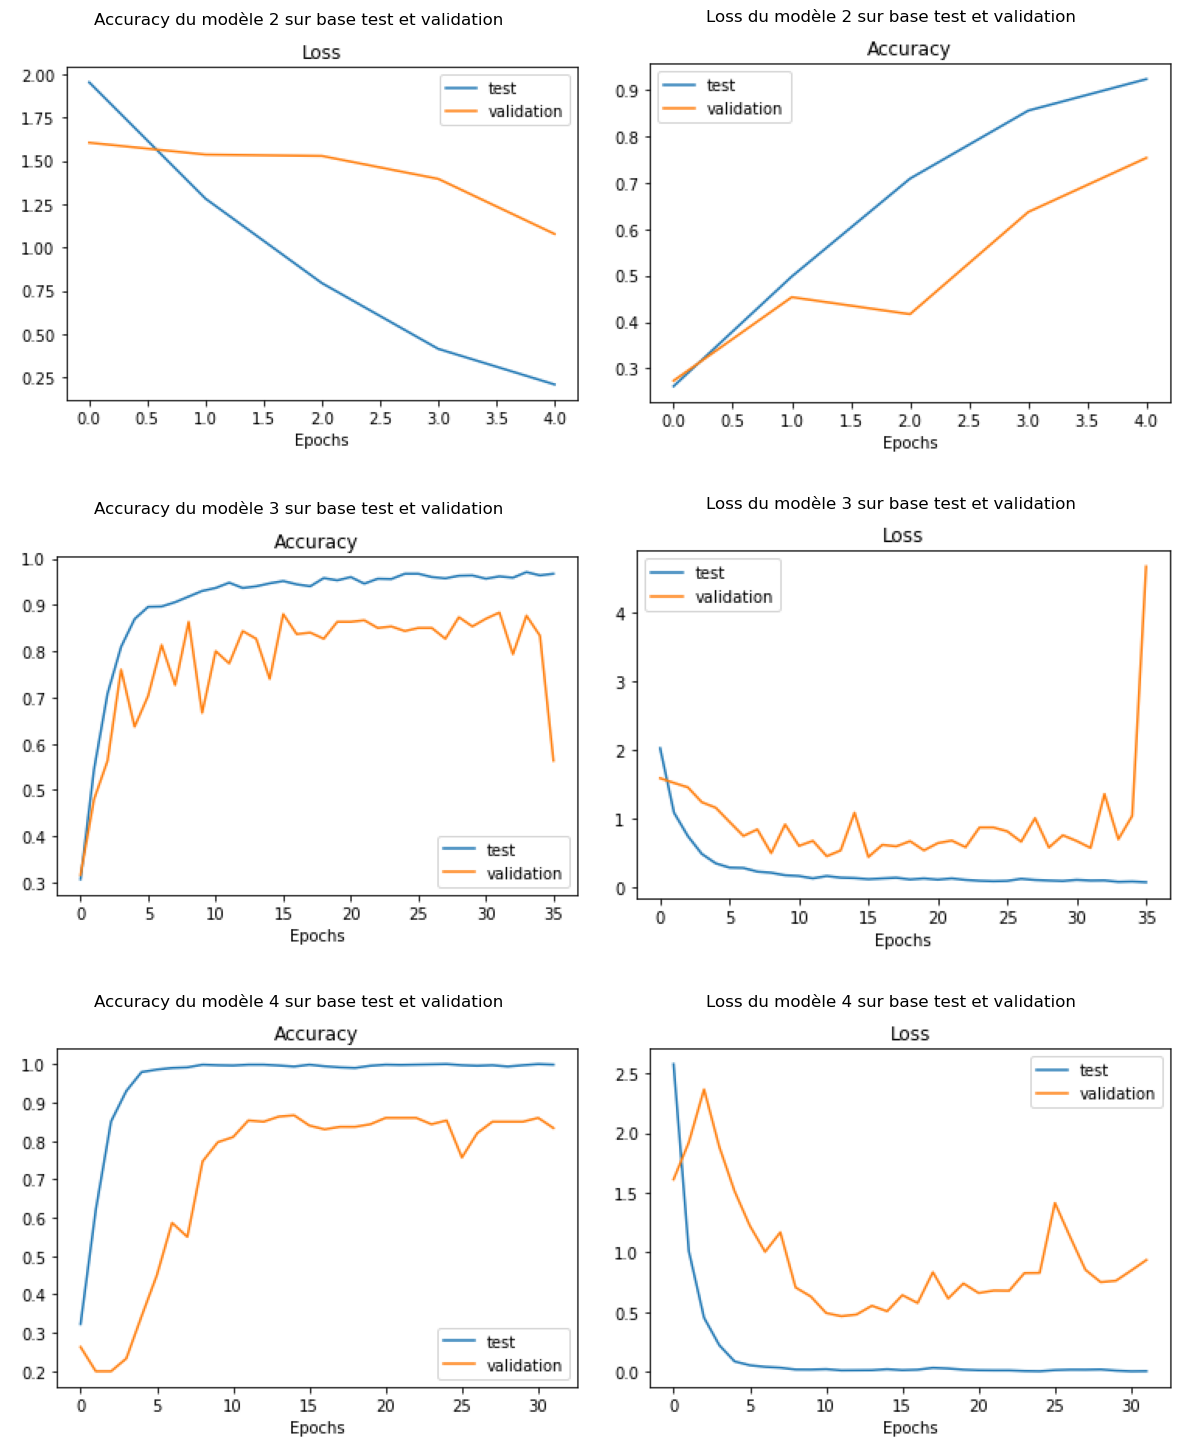

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

axes[0, 0].imshow(mpimg.imread('mod2courbeacc.png'))
axes[0, 0].set_title('Accuracy du modèle 2 sur base test et validation')
axes[0, 0].axis('off')

axes[0, 1].imshow(mpimg.imread('mod2courbeloss.png'))
axes[0, 1].set_title('Loss du modèle 2 sur base test et validation')
axes[0, 1].axis('off')

axes[1, 0].imshow(mpimg.imread('mod3courbeacc.png'))
axes[1, 0].set_title('Accuracy du modèle 3 sur base test et validation')
axes[1, 0].axis('off')

axes[1, 1].imshow(mpimg.imread('mod3courbeloss.png'))
axes[1, 1].set_title('Loss du modèle 3 sur base test et validation')
axes[1, 1].axis('off')

axes[2, 0].imshow(mpimg.imread('mod4courbeacc.png'))
axes[2, 0].set_title('Accuracy du modèle 4 sur base test et validation')
axes[2, 0].axis('off')

axes[2, 1].imshow(mpimg.imread('mod4courbeloss.png'))
axes[2, 1].set_title('Loss du modèle 4 sur base test et validation')
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

Le modèle 2 bien qu'il n'ait été réalisé que sur 5 epochs, présente une accuracy bien supérieure au premier modèle. En revanche, même s’il présente une diminution progressive de sa fonction loss, le nombre d’epochs est insuffisant pour conclure sur sa convergence ou sa capacité de généralisation. De plus, son accuracy n’est pas suffisante pour le définir comme meilleur modèle.

Le modèle 3 atteint une accuracy élevée sur l’entraînement (0.97), mais une performance plus faible sur la validation, ce qui implique un léger surapprentissage, même si sa courbe de loss semble indiquer une bonne stabilisation de la valeur du loss.

Le modèle 4 améliore la stabilité du loss au détriment de son accuracy, de plus l’écart entre les valeurs de la dernière epoch montre encore un surapprentissage.

Avec toutes ces observations, on a alors pu construire un dernier modèle.

### 2.1.c. Dernier Modèle

Ce réseau est composé de 4 couches de convolution avec respectivement 10, 20, 30 et 40 filtres de taille 3x3 pour la 1e, 2e, 3e et 4e couche ainsi que 100 neurones sur la couche dense pour 40 epochs au total. Par rapport au modèle précédent, on a ajouté une couche de convolution puis nous avons aussi drastiquement diminué le nombre de filtres par couche de convolution. Ces modifications ont été réalisées dans le but d’améliorer l’apprentissage du modèle sur les caractéristiques générales et ainsi éviter qu’il apprenne les données par cœur (éviter le risque de surapprentissage). L’écart entre l’accuracy de la base de validation et celle de la base d'entraînement est plus faible que sur les deux derniers modèles, le phénomène de surapprentissage est donc plus faible.

In [39]:
# ==================== Construction du modèle ==================== #


NB_CLASSES = 5;

model = models.Sequential()

# 1e couche convolutive
model.add(layers.Convolution2D(10, (3, 3), padding= 'same', input_shape=(256,256,1), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# 2e couche convolutive
model.add(layers.Convolution2D(20, (3, 3), padding= 'same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# 3e couche convolutive
model.add(layers.Convolution2D(30, (3, 3), padding= 'same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# 4e couche convolutive
model.add(layers.Convolution2D(40, (3, 3), padding= 'same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Flatten
model.add(layers.Flatten()) 

# Couche dense
model.add(layers.Dense(100, activation="relu"))
model.add(layers.Dropout(0.5))

# softmax dense classifier
model.add(layers.Dense(NB_CLASSES, activation="softmax"))

# summary du modèle
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_8 (Conv2D)            (None, 256, 256, 10)      100       
_________________________________________________________________
batch_normalization_8 (Batch (None, 256, 256, 10)      40        
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 128, 128, 10)      0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 128, 128, 20)      1820      
_________________________________________________________________
batch_normalization_9 (Batch (None, 128, 128, 20)      80        
_________________________________________________________________
max_pooling2d_9 (MaxPooling2 (None, 64, 64, 20)        0         
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 64, 64, 30)       

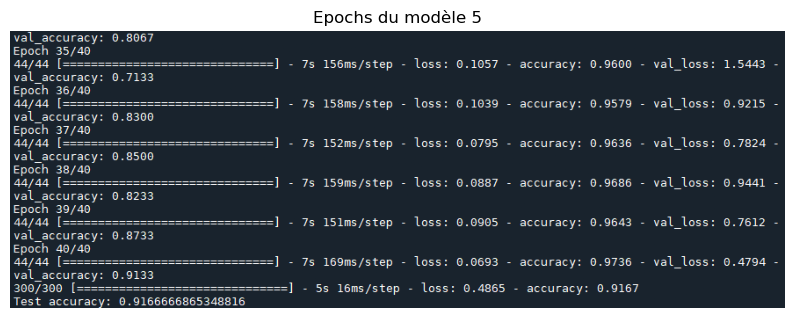

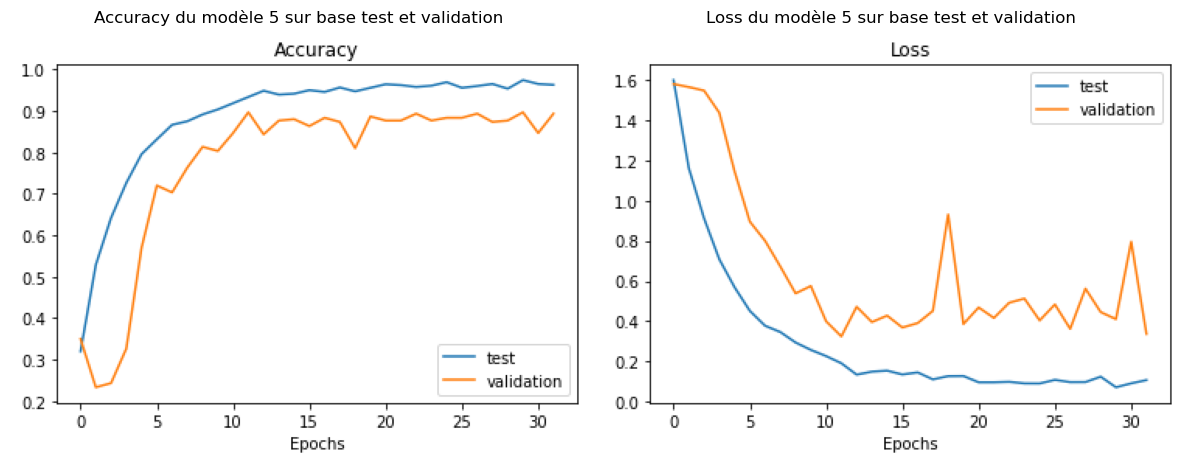

In [40]:
img = mpimg.imread('mod5perf.png')

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Epochs du modèle 5", fontsize=12)
plt.axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('mod5courbeacc.png'))
axes[0].set_title('Accuracy du modèle 5 sur base test et validation')
axes[0].axis('off')

axes[1].imshow(mpimg.imread('mod5courbeloss.png'))
axes[1].set_title('Loss du modèle 5 sur base test et validation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

On voit ainsi que le nombre de paramètres a été divisé par 100, ce qui est bénéfique pour le temps de calcul. En termes de performances, on peut apercevoir une diminution de la perte sur la base d’apprentissage et de validation. De la même manière, on peut aussi noter une meilleure précision sur ces deux bases. Ainsi, on obtient une valeur d’accuracy d’environ 91.6% sur la base de test.

L’architecture des couches de convolution permet d'extraire tout d'abord des aractéristiques globales, simples avec les premières couches puis, les motifs plus complexes avec les couches profondes. Les couches de MaxPooling2D permettent de réduire la dimensionnalité des données en conservant l’information la plus importante dans une fenêtre de recherche. De cette manière, à chaque itération, on récupère des détails tout en filtrant les zones non pertinentes. Toutefois, il est important de veiller à ne pas filtrer trop de détails à travers une réduction excessive et donc à dégrader les performances du modèle.

Enfin, l’utilisation d’un dropout de 50 % contribue également à limiter le surapprentissage en empêchant le modèle de trop se spécialiser sur les données d’entraînement, ce qui participe à l’équilibre observé entre performance et généralisation.


# 3. Réseaux pré-entraînés : VGG16

Après avoir étudié différentes architectures de CNN appliquées à nos images, nous nous intéressons désormais à l’utilisation de réseaux pré-entraînés afin d’améliorer les performances. Cette approche, appelée Transfer Learning (transfert d’apprentissage), consiste à exploiter des réseaux convolutifs profonds déjà entraînés sur de vastes bases de données. L’objectif est de tirer profit d’un réseau déjà entraîné sur une large base de données pour compenser les nôtres qui peuvent être insuffisantes pour obtenir de bonnes performances. Par ailleurs, on distingue principalement deux méthodes : l’extraction de caractéristiques (feature extraction) et l’ajustement fin (fine tuning).
Le “feature extraction” consiste à utiliser un réseau pré-entraîné comme extracteur fixe de caractéristiques, tandis que le “fine tuning” vise à réentraîner partiellement le modèle afin de l’adapter plus finement aux données étudiées. On peut préciser que nous allons tirer parti d’un réseau déjà entraîné sur une grande base de données (ImageNet) car cela permet d’améliorer les performances de notre modèle.

Le réseau pré-entraîné que nous allons exploiter est VGG16, c’est un réseau dont l’apprentissage s’est réalisé sur une très large base de données nommée ImageNet. Le but est de se servir du réseau qui a déjà appris afin de l’adapter à notre problématique en ajustant les filtres à nos besoins. En effet, on rappelle que nous travaillons sur des images médicales d’IRM et que par conséquent, ce que VGG16 a appris ne peut pas s’appliquer à nos données (trop spécifiques). C’est pour cela que nous allons utiliser une partie du réseau de VGG16 mais geler le reste tout en ajoutant des couches plus adaptées à l’extraction de nos caractéristiques. Ainsi, c’est à travers le fine tuning que nous allons mettre en œuvre notre modèle.

Comme on peut le voir ci-dessous, l’architecture complète de VGG16 comprend 13 couches de convolution, 5 couches de pooling, une couche de flattening et 3 couches denses, soit un total de 22 couches, dont 16 comportant des paramètres entraînables.

In [41]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.summary()

Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0     

Le Transfer Learning consiste à exploiter un réseau pré-entraîné en l’adaptant à un nouveau jeu de données. Pour cela, une partie des couches (notamment les couches de convolution et de pooling) est gelée afin de conserver les caractéristiques générales déjà apprises, telles que les bords, les textures ou les formes simples, qui sont pertinentes pour tout type d’images, y compris les IRM. En revanche, comme le modèle VGG16 a été initialement entraîné sur la base ImageNet, composée d’images très générales, ses couches finales ne sont pas adaptées à notre problématique. Il est donc nécessaire de les remplacer et de les réentraîner sur nos données. En d’autres termes, le gel des premières couches permet de préserver des caractéristiques globales, tandis que les dernières couches, qui se concentrent sur des caractéristiques bien plus spécifiques, vont être à nouveau entraînées mais cette fois-ci sur notre base de données.

## 3.1. Précisions des étapes pour la construction du modèle

Avant de débuter, nous allons donner quelques précisions quant aux étapes réalisées. Comme indiqué précédemment, nous utilisons un réseau pré-entraîné dont nous retirons les couches finales afin de l’adapter à nos données. Nous ajoutons ensuite de nouvelles couches de classification (couches denses) adaptées à notre problème, et réentraînons tout ou partie du modèle afin d’ajuster ses représentations à nos données.

Dans un premier temps, pour améliorer et affiner la classification, nous allons appliquer des transformations aux images de notre base d’apprentissage. Pour cela, on utilisera le module ImageDataGenerator qui, comme on l’a vu dans la partie 1, permet de modifier les images  à travers plusieurs opérations (redimensionnement, zoom, rotation, luminosité,...). De cette manière, on charge la base d’apprentissage train_generator qui va subir les modifications effectuées à travers datagen_train.

In [42]:
"""
datagen_train = ImageDataGenerator(
                                 
    rescale = 1./ 255,
    width_shift_range=0.02,
    height_shift_range=0.02,
    horizontal_flip=True,
    rotation_range=2,
    # brightness_range=[0.3, 1.7],
    zoom_range=[0.7, 1.3]
)

train_generator = datagen_train.flow_from_directory( # change rpour data augmentation
    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/train/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)
"""""

'\ndatagen_train = ImageDataGenerator(\n                                 \n    rescale = 1./ 255,\n    width_shift_range=0.02,\n    height_shift_range=0.02,\n    horizontal_flip=True,\n    rotation_range=2,\n    # brightness_range=[0.3, 1.7],\n    zoom_range=[0.7, 1.3]\n)\n\ntrain_generator = datagen_train.flow_from_directory( # change rpour data augmentation\n    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/train/",\n    target_size=(224, 224),\n    color_mode="rgb",\n    batch_size=32,\n    class_mode="categorical",\n    shuffle=True,\n    seed=42\n)\n'

Par la suite, on construit l’architecture à l’aide du module VGG16() qui prendra en argument :
-“include_top” : Indique si les couches de classification du modèle pré-entraîné sont incluses ou non. On précisera “False” car nous souhaitons classifier à partir de notre classification.
-“weights” : Spécifie les poids utilisés pour initialiser le modèle. Dans notre cas, on utilisera l’option “imagenet” pour utiliser les poids pré-entraînés sur la base de données ImageNet.
-“input_shape” : Définit la taille et le nombre de canaux des données d’entrée.

Les étapes qui suivent permettent alors de choisir l’architecture du modèle. Pour cela, on choisira dans un premier temps le nombre de couches à geler à l’aide d’une boucle for qui mettra à False toutes celles que nous souhaitons retirer parmi le nombre total de couches. Ensuite, on construira le modèle à partir d’une architecture qu’on aura déterminée.

## 3.2. Essais de différentes architectures

Dans le but de déterminer le modèle qui nous permettra d’obtenir un taux de précision de 99%, nous avons recouru à de nombreuses modifications que ce soit sur la manière dont on a transformé les images (base d’apprentissage) ou sur l’architecture du réseau en lui-même.

La construction du réseau s’est réalisée en 2 étapes : la conception du modèle et l’ajout des données fictives.

### 3.2.a. Architecture du modèle

Nous avons entraîné les modèles sur nos données d’apprentissage de base sans transformations et ce,  dans le but de déterminer une architecture qui nous convienne et pour cela, nous avons alors procédé en deux temps. Dans un premier temps, pour un nombre fixe de couches gelées, nous modifions le nombre de neurones sur les couches denses puis, dans un second temps, pour un nombre fixe de neurones sur les couches denses, nous gelons un nombre différent de couches pour déterminer le nombre optimal qui permet d’obtenir les meilleures performances.

Les tableaux ci-dessous regroupent les résultats pour les deux approches citées. On précise que le nombre d’epochs fixé est de 15 et qu’entre chaque couche dense, on inclut un dropout à 30% afin que le modèle soit plus robuste.

&nbsp;

<table>
    <tr>
    <th colspan="3" style="text-align: center;">Pour : 17 couches gelées</th>
  </tr>
  <tr>
    <th>Numéro du modèle</th>
    <th>Nb neurones 1e couche dense/nb neurones 2e couche dense</th>
    <th>Accuracy</th>
  </tr>
  <tr>
    <td>Modèle VGG16 1</td>
    <td style="text-align: center;">256/512</td>
    <td>0.94999</td>
  </tr>
    <tr>
    <td>Modèle VGG16 2</td>
    <td style="text-align: center;">28/64</td>
    <td>0.9733</td>
  </tr>
    <tr>
    <td>Modèle VGG16 3</td>
    <td style="text-align: center;">256/128</td>
    <td>0.98</td>
  </tr>
</table>

&nbsp;


<table>
    <tr>
    <th colspan="3" style="text-align: center;">Pour :
        1e couche dense : 256 neurones
        2e couche dense : 128 neurones
    </th>
  </tr>
  <tr>
    <th>Numéro du modèle</th>
    <th>Nombre de couches gelées14</th>
    <th>Accuracy</th>
  </tr>
  <tr>
    <td>Modèle VGG16 4</td>
    <td style="text-align: center;">14</td>
    <td>0.2</td>
  </tr>
    <tr>
    <td>Modèle VGG16 5</td>
    <td style="text-align: center;">16</td>
    <td>0.98</td>
  </tr>
    <tr>
    <td>Modèle VGG16 6</td>
    <td style="text-align: center;">15</td>
    <td>0.95999</td>
  </tr>
</table>

Pour une meilleure visualisation des performances nous avons tracé l’évolution du loss et de l’accuracy sur la base de test et de validation sur les modèles 2, 3 et 4.

#### Modèle VGG16 2 :


0 input_2 False
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 False
10 block3_pool False
11 block4_conv1 False
12 block4_conv2 False
13 block4_conv3 False
14 block4_pool False
15 block5_conv1 False
16 block5_conv2 False
17 block5_conv3 True
18 block5_pool True
Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten_6 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dense_14 (Dense)             (None, 28)                702492    
_________________________________________________________________
dropout_8 (Dropout)          (None, 28)               

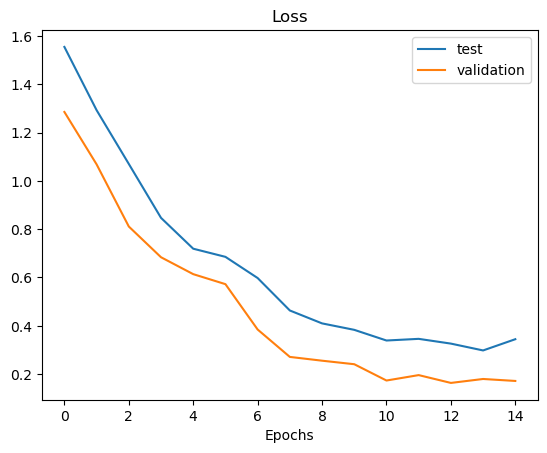

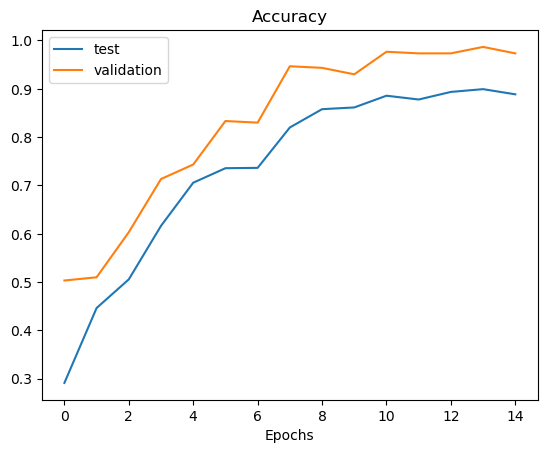

In [43]:
# ==================== Construction du modèle ==================== #


# Les paramètres des 17 premières couches sont gelés
for layer in base_model.layers[:17]:
    layer.trainable = False

# Pour voir quelles sont les couches entraînables
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)
     
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(28,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
        
    layers.Dense(NB_CLASSES, activation='softmax')
])

model.summary()


# ==================== Compilation ==================== #


# Compiling the model
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 15
VERBOSE = 1

history=model.fit(train_generator, epochs=EPOCHS, verbose=VERBOSE, validation_data=valid_generator,callbacks=[cb])
# models.load_model(checkpoint_filepath)


# ==================== Évalution du modèle ==================== #


test_loss, test_acc = model.evaluate(test_generator)

print('Test accuracy:', test_acc)
print(history.history.keys())
plt.figure()
plt.plot(history.history['loss'], label='test')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel("Epochs")
plt.title("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='test')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel("Epochs")
plt.title("Accuracy")
plt.legend()
plt.show()

Ce modèle présente un certain écart lors du calcul de l’accuracy et du loss. En effet, on remarque que l’accuracy calculée sur la base de test est plus faible que celle calculée sur la base de validation. De plus, on a une erreur plus importante sur la base de test que sur la base de validation. Cependant, ce modèle offre une accuracy de 97%, c’est donc un modèle qui généralise relativement bien mais qui a encore du mal à classifier correctement nos données.

#### Modèle VGG16 3 :

Pour éviter de relancer tout l'entraînement, nous avons directement affiché les courbes associées au modèle 3 de VGG16.

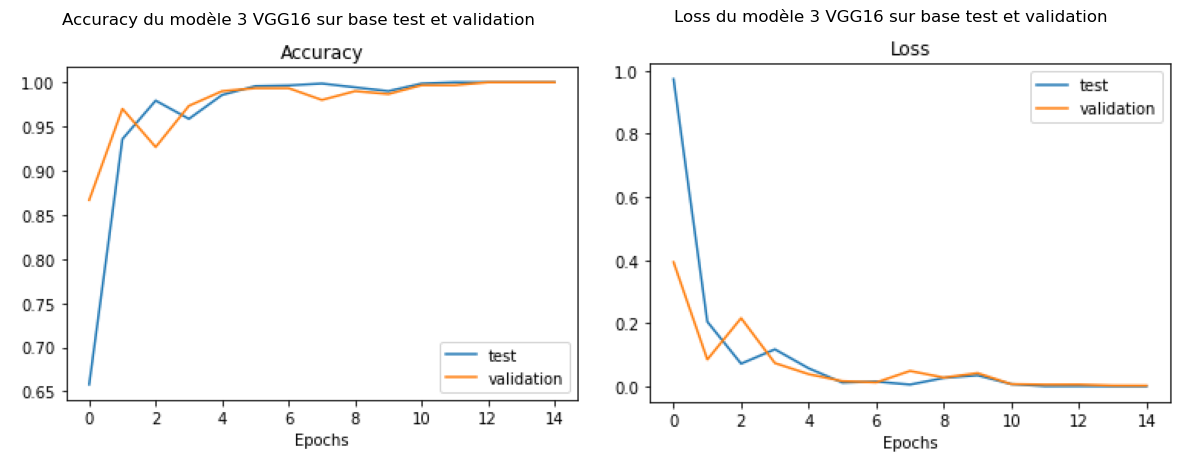

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('vgg16_courbe_acc_final.png'))
axes[0].set_title('Accuracy du modèle 3 VGG16 sur base test et validation')
axes[0].axis('off')

axes[1].imshow(mpimg.imread('vgg16_courbe_loss_final.png'))
axes[1].set_title('Loss du modèle 3 VGG16 sur base test et validation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Ce modèle présente une accuracy sur la base de test qui est extrêmement proche de la valeur que l’on exige (0.99) et de l’accuracy sur la base de validation. De plus, la valeur de loss est elle aussi stabilisée aux alentours de 0.05, ce qui démontre un apprentissage qui pourrait potentiellement réaliser une très bonne classification avec très peu d’erreurs. Par ailleurs, on remarque que ce modèle finit son apprentissage aux alentours de 10 epochs. En somme, ce modèle est meilleur que celui étudié précédemment avec notamment une meilleure précision sur les deux bases ainsi qu’une erreur plus faible et un temps de calcul moins long.

#### Modèle VGG16 4 :


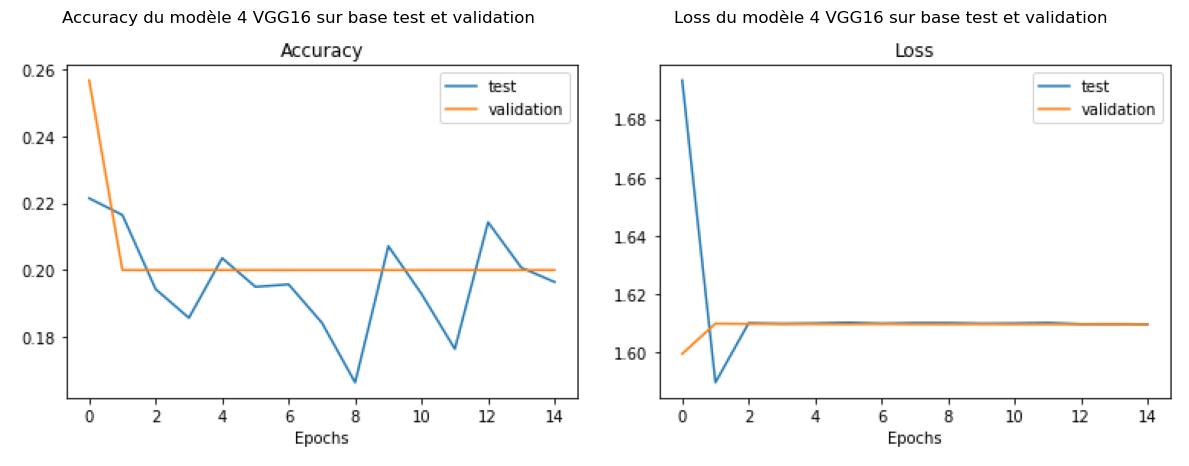

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('vgg16_layer14_accuracy.png'))
axes[0].set_title('Accuracy du modèle 4 VGG16 sur base test et validation')
axes[0].axis('off')

axes[1].imshow(mpimg.imread('vgg16_layer14_loss.png'))
axes[1].set_title('Loss du modèle 4 VGG16 sur base test et validation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Pour ce modèle, nous avons gelé 14 couches et on observe un phénomène assez particulier avec l’accuracy et le loss sur la base de validation qui deviennent constants dès les premières epochs. En effet, on voit que l’accuracy se bloque à 0.2 sans variations par la suite. Nous avons réitéré l’expérience en gelant 6, 12 et 15 couches et le résultat est similaire :  la valeur d’accuracy se stabilise très rapidement à 0.2 ainsi que le loss à 1.61.

C’est la conséquence directe de l’architecture de VGG16, ainsi que de sa base de données ImageNet, qui se compose de 5 blocs. Ainsi, les premiers blocs permettent l’extraction de caractéristiques simples et globales, puis ceux qui suivent se concentrent davantage sur des caractéristiques plus fines. C’est pour cette raison que le nombre de couches gelées a son importance : moins on gèle de couches et plus on casse l’apprentissage car on entraîne davantage de couches qui sont nécessaires à l’extraction de features simples et qui, par conséquent, ne devraient pas être entraînables.

En somme, d’après le tableau et les courbes tracées,  on en déduit que l’architecture la plus performante se compose donc  de 17 couches gelées pour VGG16 ainsi que de 3 couches de denses dont 256 neurones pour la première, 128 pour la deuxième et 5 pour la troisième car elle réalise la classification finale. Ce modèle permet d’obtenir une valeur d’accuracy la plus élevée tout en maintenant une valeur de loss faible et en évitant un surapprentissage.

### 3.2.b. Ajout de données fictives

Après avoir déterminé cette architecture, nous allons en déduire les transformations adéquates apportées aux images de la base d’apprentissage. 

À partir du module ImageDataGenerator, nous allons :
-Normaliser les pixels à l’aide du paramètre “rescale”
-Décaler l’image horizontalement avec “width_shift_range”
-Décaler l’image verticalement avec “height_shift_range”
-Retourner l’image horizontalement avec “horizontal_flip”
-Modifier la luminosité avec “brightness_range”
-Zoomer avant/arrière avec “zoom_range”

Nous avons alors réalisé 3 essais pour finalement convenir des modifications que nous allons conserver.

#### 1e essai :


In [46]:
# 1e essai :
    
datagen_train = ImageDataGenerator(
    rescale = 1./ 255,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    rotation_range=2,
    brightness_range=[0.9, 1.1],
    zoom_range=[0.9, 1.1]
)

train_generator = datagen_train.flow_from_directory( # change rpour data augmentation
    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/train/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

# accuracy : 0.9633

Found 1400 images belonging to 5 classes.


0 input_2 False
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 False
10 block3_pool False
11 block4_conv1 False
12 block4_conv2 False
13 block4_conv3 False
14 block4_pool False
15 block5_conv1 False
16 block5_conv2 False
17 block5_conv3 True
18 block5_pool True
Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten_7 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dense_17 (Dense)             (None, 256)               6422784   
_________________________________________________________________
dropout_10 (Dropout)         (None, 256)              

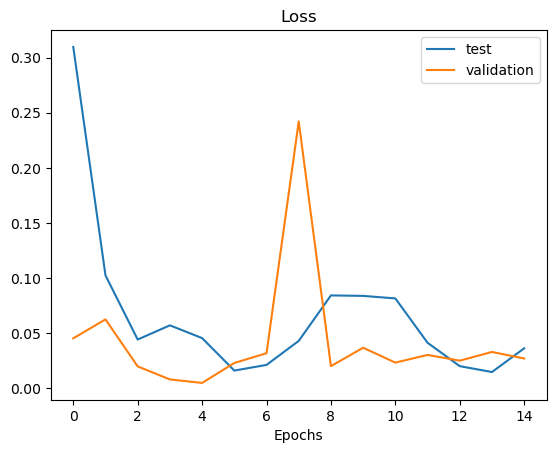

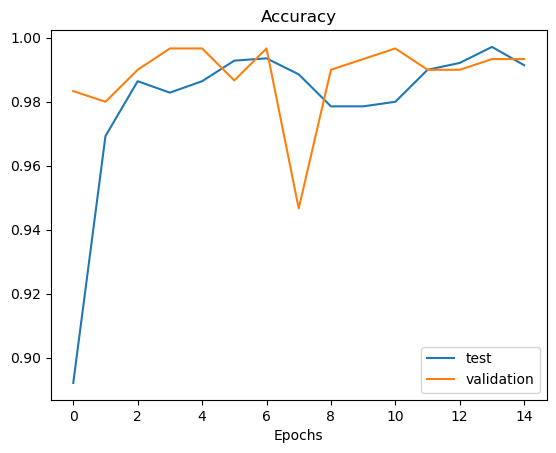

In [47]:
# Les paramètres des 17 premières couches sont gelés
for layer in base_model.layers[:17]:
    layer.trainable = False

# Pour voir quelles sont les couches entraînables
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)
     
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
        
    layers.Dense(NB_CLASSES, activation='softmax')
])

model.summary()


# ==================== Compilation ==================== #


# Compiling the model
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS = 15
VERBOSE = 1

history=model.fit(train_generator, epochs=EPOCHS, verbose=VERBOSE, validation_data=valid_generator,callbacks=[cb])
# models.load_model(checkpoint_filepath)


# ==================== Évaluation du modèle ==================== #


test_loss, test_acc = model.evaluate(test_generator)

print('Test accuracy:', test_acc)
print(history.history.keys())
plt.figure()
plt.plot(history.history['loss'], label='test')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel("Epochs")
plt.title("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='test')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel("Epochs")
plt.title("Accuracy")
plt.legend()
plt.show()

À partir des courbes ci-dessus, on souligne que la data augmentation et notamment avec l’utilisation de données fictives a un impact sur l’accuracy et la valeur de loss du modèle. En effet, l’accuracy obtenue est de 0.96 avec data augmentation tandis que sans data augmentation, l’accuracy du modèle était de 0.99. On note alors que ces transformations ne s’adaptent pas correctement à nos images d’IRM.

#### 2e essai :

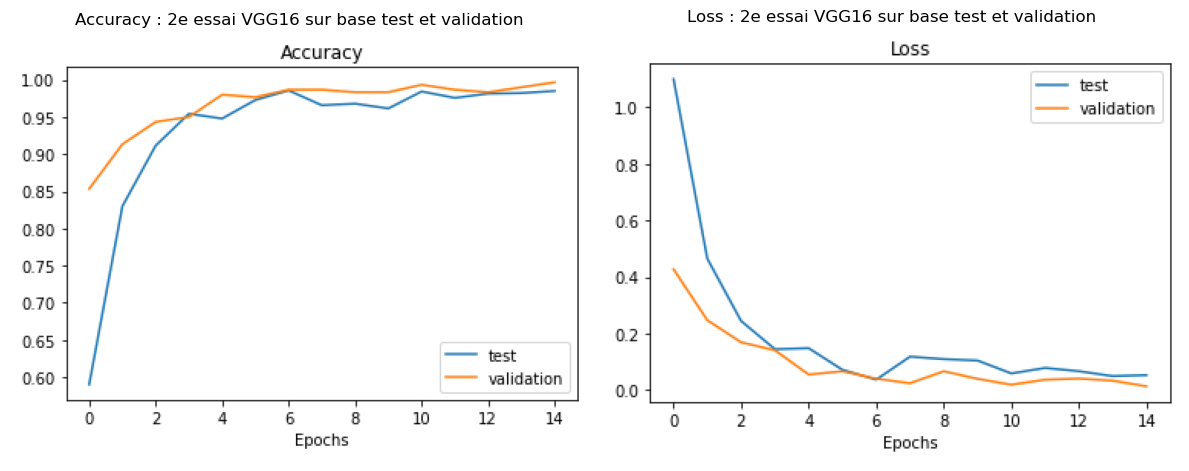

In [50]:
# 2e essai :
 
datagen_train = ImageDataGenerator(
        rescale = 1./ 255,
        width_shift_range=0.02,
        height_shift_range=0.02,
        horizontal_flip=True,
        rotation_range=2,
        brightness_range=[0.3, 1.7],
        zoom_range=[0.9, 1.1]
    )

# accuracy : 0.97

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('vgg16_2e_essai_accuracy.png'))
axes[0].set_title('Accuracy : 2e essai VGG16 sur base test et validation')
axes[0].axis('off')

axes[1].imshow(mpimg.imread("vgg16_2e_essai_loss.png"))
axes[1].set_title('Loss : 2e essai VGG16 sur base test et validation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Dans le but de nous rapprocher le plus possible d’une accuracy de 0,99, nous avons modifié les transformations appliquées aux images. On a alors élargi l’intervalle de luminosité, mais aussi modifié l’angle de décalage. Les résultats obtenus sont relativement meilleurs mais on ne dépasse pas 0.97 en termes d’accuracy, cependant la valeur de loss est toujours très faible, ce qui montre que le modèle a peu de chance de se tromper.

#### 3e essai :

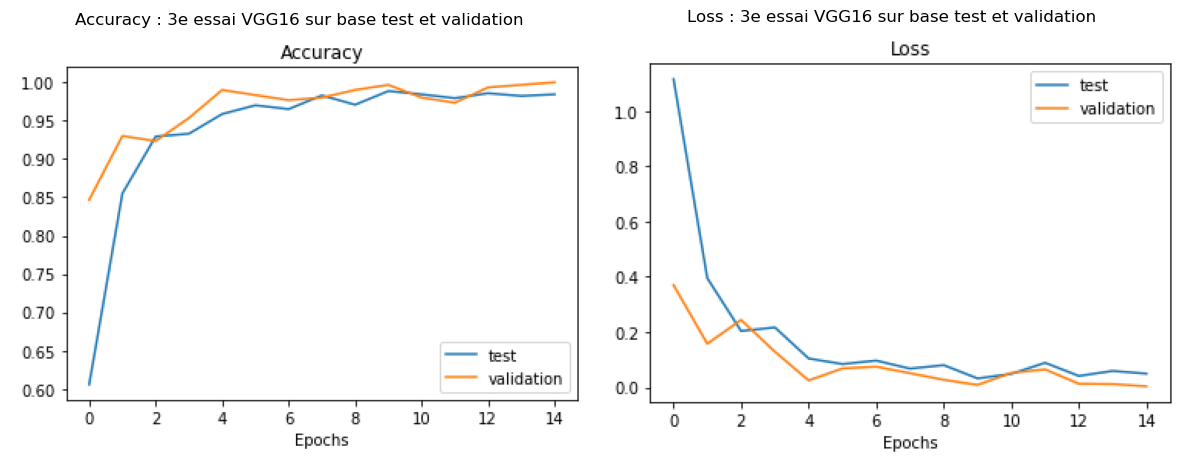

In [51]:
# 3e essai :
    
datagen_train = ImageDataGenerator(
    rescale = 1./ 255,
    width_shift_range=0.02,
    height_shift_range=0.02,
    horizontal_flip=True,
    rotation_range=2,
    # brightness_range=[0.3, 1.7],
    zoom_range=[0.7, 1.3]
)

# accuracy : 0.99

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('vgg16_3e_accuracy.png'))
axes[0].set_title('Accuracy : 3e essai VGG16 sur base test et validation')
axes[0].axis('off')

axes[1].imshow(mpimg.imread("vgg16_3e_loss.png"))
axes[1].set_title('Loss : 3e essai VGG16 sur base test et validation')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Finalement, pour ce dernier essai nous avons tout simplement décidé de ne pas modifier la luminosité car, travaillant sur des données médicales, la luminosité est une caractéristique importante qui permet l’observation d’informations qui pourraient être perdues ou corrompues contrairement aux autres paramètres d'ImageDataGenerator qui agissent principalement sur la géométrie de l’image. De cette manière, nous obtenons une valeur d’accuracy qui plafonne à 99% comme ce que nous souhaitions.

#### Architecture finale de notre modèle :

À partir de tous les essais effectués et des comparaisons réalisées, nous en avons conclu que la meilleure architecture se compose de :
-16 couches de VGG16 gelées pour l’extraction de features générales
-1e couche dense avec 256 neurones
-2e couche dense avec 128 neurones
-3e couche dense avec 5 neurones pour la classification finale
-2 couches de dropout à 30%

Pour ce qui concerne la transformation de nos images, on applique une normalisation de nos données ainsi qu’un décalage horizontal et vertical de 2% puis un retournement horizontal de l’image ainsi qu’une rotation aléatoire entre -2° et +2° et enfin un zoom aléatoire entre 0.7 et 1.3.


# 4. Analyse des résultats

Après avoir pré-entraîner notre réseau avec le VGG16 (17 couches gelées,256 neurones sur la première couche dense et 128 sur la seconde), il nous faut l’enregistrer pour ne pas avoir à le ré-entraîner dès que l’on veut l’utiliser.
Pour cela il faut enregistrer le modèle au format JSON grâce à la fonction to_json(), ce qui nous permet de garder toute l’architecture du réseau (le nombre de couches, leur type, les fonctions d’activation, …). En revanche,  cette structure ne contient pas les données acquises lors de l'entraînement (les poids), il faut donc dans un autre fichier (model.h5) sauvegarder tous les poids avec la fonction save_weights().
On pourra alors utiliser ces deux fichiers pour “recharger” le modèle sans avoir à le ré-entraîner, pour analyser les performances et la classification de notre modèle.

## 4.1. Extraction des filtres et images filtrées après VGG16

Pour évaluer les performances, il est d’abord nécessaire de bien visualiser l’architecture de notre modèle afin de l’exploiter correctement. La figure ci-dessous met en avant la structure complète de notre modèle que que nous avons détaillée dans la partie 2.2.b.

In [52]:
# Chargement de notre model -> architecture et paramètres
model_architecture = 'model.json' # Architecture
model_weights = 'model.h5'        # Poids
model = model_from_json(open(model_architecture).read()) # Permet de récupérer el model
model.load_weights(model_weights) # Chargement des poid/paramètres qui engendrent los puntos
model.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten_7 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dense_21 (Dense)             (None, 256)               6422784   
_________________________________________________________________
dropout_14 (Dropout)         (None, 256)               0         
_________________________________________________________________
dense_22 (Dense)             (None, 128)               32896     
_________________________________________________________________
dropout_15 (Dropout)         (None, 128)               0         
_________________________________________________________________
dense_23 (Dense)             (None, 5)                

Notre objectif ici est d’observer quelques filtres appliqués durant les convolutions. Pour cela, on se place dans la première couche de notre modèle qui correspond alors à l’ensemble des couches de VGG16 comme on peut le voir ci-dessous :

In [53]:
base_model = model.layers[0] # Récupéracion de la première couche
base_model.summary()

Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_8 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0     

À partir de l’image ci-dessus, on voit que le modèle se compose de 2 359 808 paramètres entraînables, ce qui montre que le modèle a la capacité de généraliser les informations sans mémoriser par cœur les données. Cela rejoint ce que l’on disait dans la partie 1. à propos du nombre de paramètres entraînables. Il est vrai que posséder un grand nombre de paramètres permet d’obtenir un modèle puissant et très efficace localement mais cela implique une non-capacité à généraliser car il ne prend pas assez en compte les caractéristiques simples. Ce modèle comporte alors un nombre raisonnable de paramètres qui permettra alors de classifier correctement les données.

#### Filtres bas niveau

Tout d’abord, nous allons visualiser les filtres du noyau de convolution block1_conv1 et pour cela on récupère les poids de cette première couche. Cela permet d’obtenir les filtres utilisés dans l’extraction des caractéristiques simples de l’image, telles que les bords, les contours ou encore les variations d’intensité, etc.
L’image étant considérée comme une image en RGB, on va récupérer les filtres sur les 3 canaux (rouge, vert et bleu). Les filtres sont ensuite normalisés afin d’améliorer leur visualisation.


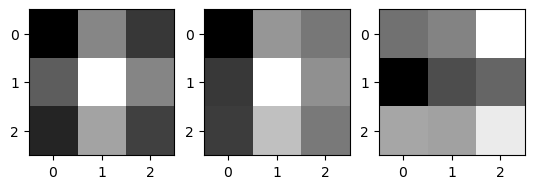

In [54]:
# Récupérer les filtres et les poids de la 1ère couche
filters, biases, *is_anything_else_being_returned = base_model.layers[1].get_weights()

# Normalisation des filtres sur [0 , 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Prendre le deuxième filtre de cette couche (qui contient 3 sous-filtres pour les 3 canaux R,
# V et et B) et visualiser ces 3 sous-filtres
f=filters[:,:,:,1]
plt.subplot(1,3,1)
plt.imshow(f[:, :, 0], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(f[:, :, 1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f[:, :, 2], cmap='gray')

Avant de produire les images filtrées, elles doivent être remaniées pour pouvoir passer dans le modèle au format attendu. L’image doit tout d’abord être convertie en un tableau de valeurs float pour permettre les opérations numériques. Elle doit ensuite être redimensionnée au format du modèle  (224x224x3), puis normalisée pour une meilleure visualisation.
Enfin, une opération de reshape() est appliquée afin d’ajouter une dimension supplémentaire correspondant à la taille du batch. En effet, les modèles de type VGG16 attendent une entrée sous la forme d’un tenseur à 4 dimensions (batch_size, hauteur, largeur, canaux). Dans notre cas, le reshape([-1, 224, 224, 3]) permet donc de transformer une seule image en un batch de taille 1, le -1 sert uniquement à calculer automatiquement la dimension manquante. On rappelle que le batch size correspond au nombre d’images traitées simultanément par le modèle, ici on en traite seulement une à la fois.

Pour visualiser réellement l’image obtenue à un layer du modèle voulu, il faut encore construire un modèle intermédiaire, tronqué à la ligne voulue, soit la première couche ici. Cela permet d’obtenir les cartes de caractéristiques (feature maps), correspondant à la réponse des différents filtres de la couche choisie pour une image d’entrée donnée. L’image est ensuite passée dans ce modèle intermédiaire à l’aide de la fonction predict(), ce qui permet de récupérer l’image filtrée sous forme de tenseur.


Model: "model_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Total params: 1,792
Trainable params: 0
Non-trainable params: 1,792
_________________________________________________________________


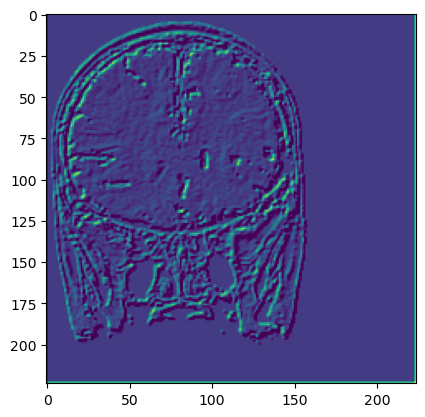

In [55]:
img_tst = Image.open(r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/test/hallervorden_spatz_disease\hallervorden_spatz_disease_test_0004.jpg")
image = np.asarray(img_tst)
image=image.astype('float32')
image=cv2.resize(image,(224,224))
image /= 255
image = image.reshape([-1,224,224,3])

from keras.models import Model
inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[1].output)
inter_model.summary()
feature_maps = inter_model.predict(image)
plt.figure()
plt.imshow(feature_maps[0,:,:,0])

On pourra alors visualiser l’effet de ces filtres sur des images pour la base de test.


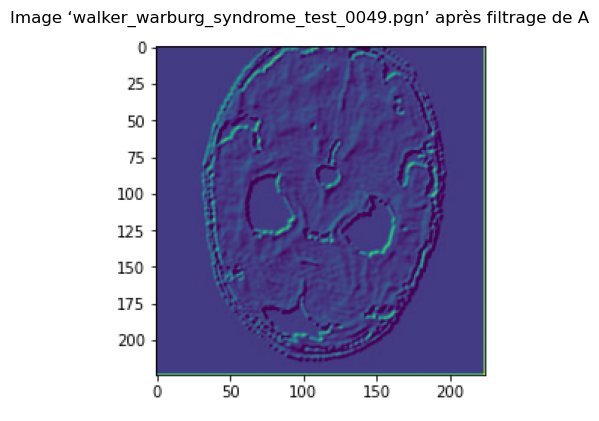

In [56]:
img = mpimg.imread('walkerlayer1.png')

plt.figure(figsize=(5, 6))
plt.imshow(img)
plt.title("Image ‘walker_warburg_syndrome_test_0049.pgn’ après filtrage de A", fontsize=12)  # Ajouter un titre
plt.axis('off')
plt.show()

Ces filtres, qui appartiennent à un niveau d'extraction de caractéristiques bas, semblent segmenter les contours, ceci est cohérent avec les explications données précédemment.

#### Filtres intermédiaires

Pour les  filtres d’extraction de caractéristiques de niveau  plus haut, on aura des motifs de plus en plus complexes ainsi que des dimensions plus petites, les images seront de plus en plus pixelisées jusqu’à devenir monochromatiques. Les motifs qui ressortiront au fur et à mesure de la complexité du réseau ne seront plus forcément des éléments observables à l'œil nu mais des concepts plus abstraits que le réseau entraîné réussira à extraire. L’interprétation humaine de l’image sera donc de plus en plus difficile.

Model: "model_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Total params: 2,915,648
Trainable params: 0
Non-trainable params: 2,915,648
_________________________________________________________________


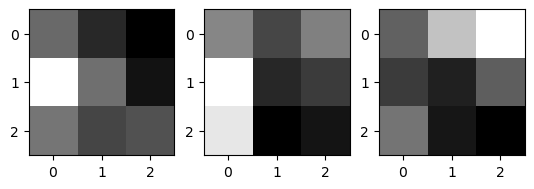

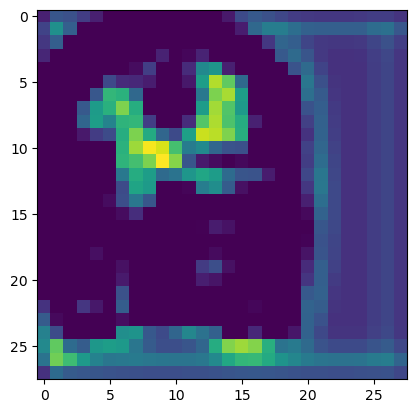

In [57]:
# Récupération des filtres sur la 10e couche
filters, biases, *is_anything_else_being_returned = base_model.layers[11].get_weights()

# Normalisation des filtres sur [0 , 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Prendre le deuxième filtre de cette couche (qui contient 3 sous-filtres pour les 3 canaux R,
# V et et B) et visualiser ces 3 sous-filtres
f=filters[:,:,:,1]
plt.subplot(1,3,1)
plt.imshow(f[:, :, 0], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(f[:, :, 1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f[:, :, 2], cmap='gray')

inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[11].output)
inter_model.summary()
feature_maps = inter_model.predict(image)
plt.figure()
plt.imshow(feature_maps[0,:,:,0])

Ces filtres permettent d’extraire des détails très abstraits. On voit alors que plus on avance dans le réseau et plus l’extraction des caractéristiques est fine, le réseau se concentre davantage sur les détails.

#### Filtres haut niveau


Model: "model_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Total params: 12,354,880
Trainable params: 0
Non-trainable params: 12,354,880
_________________________________________________________________


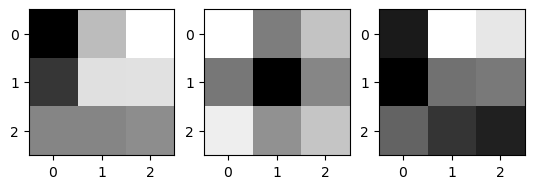

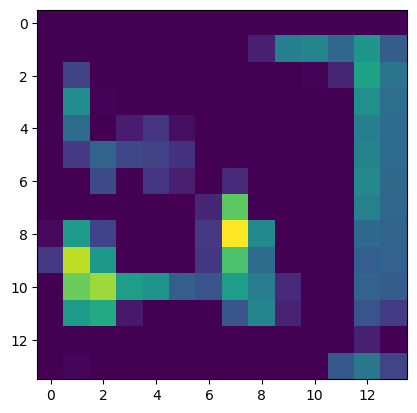

In [58]:
# Récupération des filtres sur la 15e couche
filters, biases, *is_anything_else_being_returned = base_model.layers[16].get_weights()

# Normalisation des filtres sur [0 , 1]
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Prendre le deuxième filtre de cette couche (qui contient 3 sous-filtres pour les 3 canaux R,
# V et et B) et visualiser ces 3 sous-filtres
f=filters[:,:,:,1]
plt.subplot(1,3,1)
plt.imshow(f[:, :, 0], cmap='gray')
plt.subplot(1,3,2)
plt.imshow(f[:, :, 1], cmap='gray')
plt.subplot(1,3,3)
plt.imshow(f[:, :, 2], cmap='gray')

inter_model = Model(inputs=base_model.inputs, outputs=base_model.layers[16].output)
inter_model.summary()
feature_maps = inter_model.predict(image)
plt.figure()
plt.imshow(feature_maps[0,:,:,0])


Ici, on voit que plus on avance dans le réseau et plus les features extraites sont fines et détaillées.

## 4.2. Analyses des performances du modèle

On peut comme dans la partie où l’on avait généré le modèle, utiliser ImageDataGenerator() afin de préparer les données pour le modèle.

De la même manière, les images sont ensuite chargées avec la fonction flow_from_directory(), à nouveau le paramètre shuffle est mis comme False pour garder l’ordre des images, ce qui nous permettra d’évaluer correctement le modèle.

L’évaluation du modèle se fera de la manière suivante : pour chaque image de la base test, un vecteur de probabilité sera associé, on associera alors la classe la plus probable en prenant la valeur maximum de ce vecteur. On récupérera les vraies classes par la même occasion ce qui nous permettra de comparer si ce que l’on prédit sera réellement bien classé ou pas. On affichera alors la matrice de confusion des éléments prédits par rapport aux éléments réels ainsi que la précision, le recall, le F1-score et le support.


In [59]:
# ========================= Évaluation des performances ========================= #


test_datagen = ImageDataGenerator(
        #rotation_range=40,
        #width_shift_range=0.2,
        #weight_shift_range=0.2,
        rescale=1./255,       # Normalisation des valeurs : 0-255
        #shear_range=0.2,
        #zoom_range=0.2,
        #horizontal_flip=True,
        #fill_mode='nearest'
        )

test_generator = test_datagen.flow_from_directory(
    directory=r"E:/S2 cle/Apprentissage auto/tp_projet_im_classe/test/",
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=1,
    class_mode="categorical",
    shuffle=False, # True : prise aléatoire/False : contraire
)

y_pred_prob=model.predict(test_generator)    # Création du vecteur de proba.
y_pred=np.argmax(y_pred_prob, 1)             # Sélection de la val. max
labels = test_generator.classes              # Récupération des classes
print(confusion_matrix(labels, y_pred))      # Matrice de confusion
print(classification_report(labels, y_pred)) # Affiche les performances

Found 300 images belonging to 5 classes.
[[60  0  0  0  0]
 [ 0 59  1  0  0]
 [ 0  0 60  0  0]
 [ 0  0  0 60  0]
 [ 0  0  0  0 60]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      0.98      0.99        60
           2       0.98      1.00      0.99        60
           3       1.00      1.00      1.00        60
           4       1.00      1.00      1.00        60

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



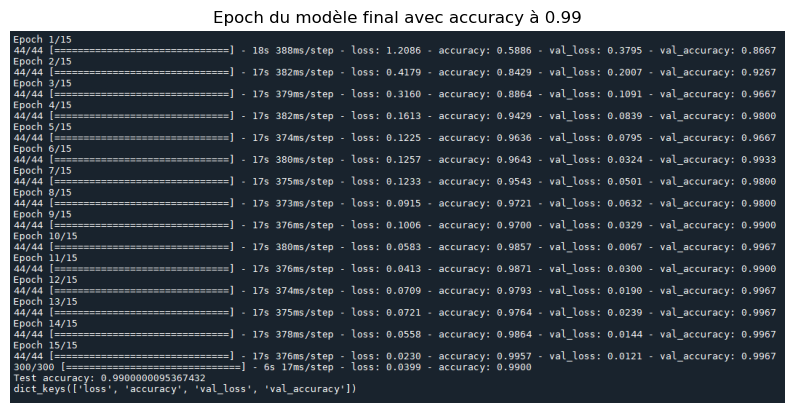

In [60]:
img = mpimg.imread('ecosses.png')

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Epoch du modèle final avec accuracy à 0.99", fontsize=12)  # Ajouter un titre
plt.axis('off')
plt.show()

La matrice confusion associée démontrait alors une très bonne classification des images avec seulement une seule image mal classifiée (classe 2 au lieu de la classe 1). La majorité des résultats de la classification se trouvent sur la diagonale ce qui est cohérent car nous avons une bonne répartition dans les classes.

La précision permet de savoir avec quelle justesse le modèle prédit la bonne classe. On observe donc que seule la classe 2 ne permet pas de prédire correctement sa classe dans son entièreté. C’est ce que l’on remarque dans la matrice de confusion où un élément de la classe 1 a été classé comme élément de la classe 2. Dans la globalité, le modèle reste très performant pour prédire la bonne classe.

Le Recall indique avec quelle efficacité le modèle parvient à capturer tous les éléments réels d'une classe. Ce qui est cohérent avec la précision et la matrice de confusion. L’élément de la classe 1 a été classé classé dans la classe 2 donc la classe 1 ne permet pas de récupérer tous les éléments qui sont supposés y être.

Le F1-score permet de faire la moyenne harmonique entre le recall et la précision. On observe bien que les classes 1 et 2 ne sont pas classées parfaitement ce qui est cohérent avec ce qui a été dit précédemment.

Le support montre juste le nombre d’images appartenant réellement à chaque classe.

La moyenne macro (macro avg) calcule la performance moyenne sur toutes les images sans tenir compte de leurs classes. Ainsi, puisque les scores de précision, recall et F1-score sont tous à 1, ou des valeurs arrondies très proches de 1 pour les 300 images, on peut en déduire que le modèle est excellent.

La Weighted Average calcule la moyenne en donnant plus d'importance aux classes qui ont le plus d'images (le support).

Ce modèle permettait donc de classifier les images de la base test quasiment parfaitement.

# 5. Classification à l’aide d’une API

## 5.1. L'API

Pour pouvoir utiliser simplement le modèle en tant qu’application web grâce à une interface, on utilisera la bibliothèque streamlit pour créer une API.

À l’aide du programme ‘vgg_image_classification.py’, on importe le modèle VGG19.

À partir de ce modèle, on peut créer une API avec le programme ‘streamlit2.py’. Ce dernier code nous permet d’utiliser le VGG19 déjà entraîné sur la base de données ImageNet. 

Dans un premier temps le code s’occupe de charger le modèle, puis des fonctions plutôt esthétiques de l’API. Avec une animation pendant que le modèle est en train de charger, du texte pour demander une image à classifier, le widget de l’emplacement du dépôt de l’image, et la désactivation  de warning.

Par la suite, la fonction upload_predict (upload_image, model) permet de :
-Pré-traiter l’image  pour qu'elle soit utilisable par le modèle, elle est:
-Prédire la classe associée au modèle
-Donner en sortie la classe de l’image
Puis lorsque l’on fournit une image à l’interface, elle nous affiche la classe, le pourcentage de similarité entre l’image et la classe.

Lorsque l’on fournit une image basique comme une pomme ou une voiture, le programme arrive sans problème à nous donner la bonne classe d’objet avec un pourcentage de similitude au-delà de 95%. En revanche, lorsque l’on essaye avec une image de notre base de donnée de test, sans entraînement, le modèle de base est incapable d’identifier la maladie ou même l’image en tant que partie du cerveau.

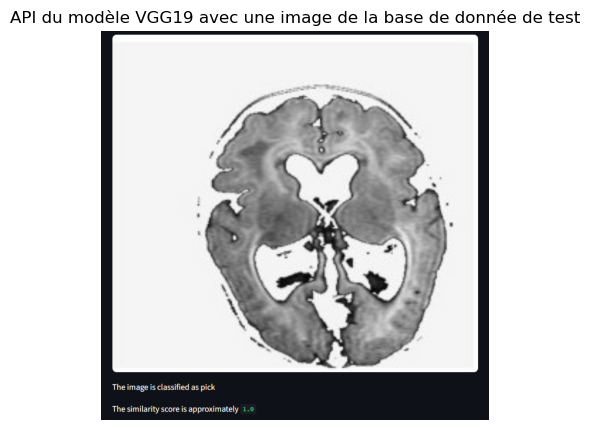

In [62]:
img = mpimg.imread('streamlit2_walker.png')

plt.figure(figsize=(5, 6))
plt.imshow(img)
plt.title("API du modèle VGG19 avec une image de la base de donnée de test", fontsize=12)
plt.axis('off')
plt.show()

On observe que non seulement la classification est fausse (soit il l’identifie comme pioche soit comme médiator), mais en plus le pourcentage de similitude est supposé de 1.0 donc exact à l’image de référence de ‘pick’

Pour pouvoir utiliser l’API pour classifier nos images, il est donc essentiel de se baser sur notre modèle avec ses poids.


## 5.2. Utilisation de l’API pour classer des images d’IRM

Nous allons désormais tester notre modèle sur la base d’images récupérées sur internet.

Tout d’abord, étudions rapidement la structure du programme “streamlit_cerv.py” que nous allons utiliser, on reprendra le programme “streamlit2.py” en le modifiant pour l’adapter à notre modèle.

Dans un premier temps, le programme charge le modèle (la structure et les poids) que nous avons enregistrés préalablement à l’aide la fonction load_model(). Par la suite, on utilise la fonction upload_predict() qui permet, à partir d’une image donnée, d’en déduire la classe à partir de la prédiction réalisée entre le modèle et notre image. De cette manière, on obtient la classe prédite ainsi que la probabilité que l’image appartienne à cette classe.

### 5.2.a. Exemples de mauvaises classifications

Nous allons désormais mettre en application notre modèle à travers ce programme et cette API. Pour tester notre modèle, nous allons nous appuyer appuyer sur des images cérébrales d’IRM trouvées sur internet et qui font partie d’une des 5 classes de maladies neurologiques que nous devons classer.

Nous avons alors tenté de classifier les images suivantes :

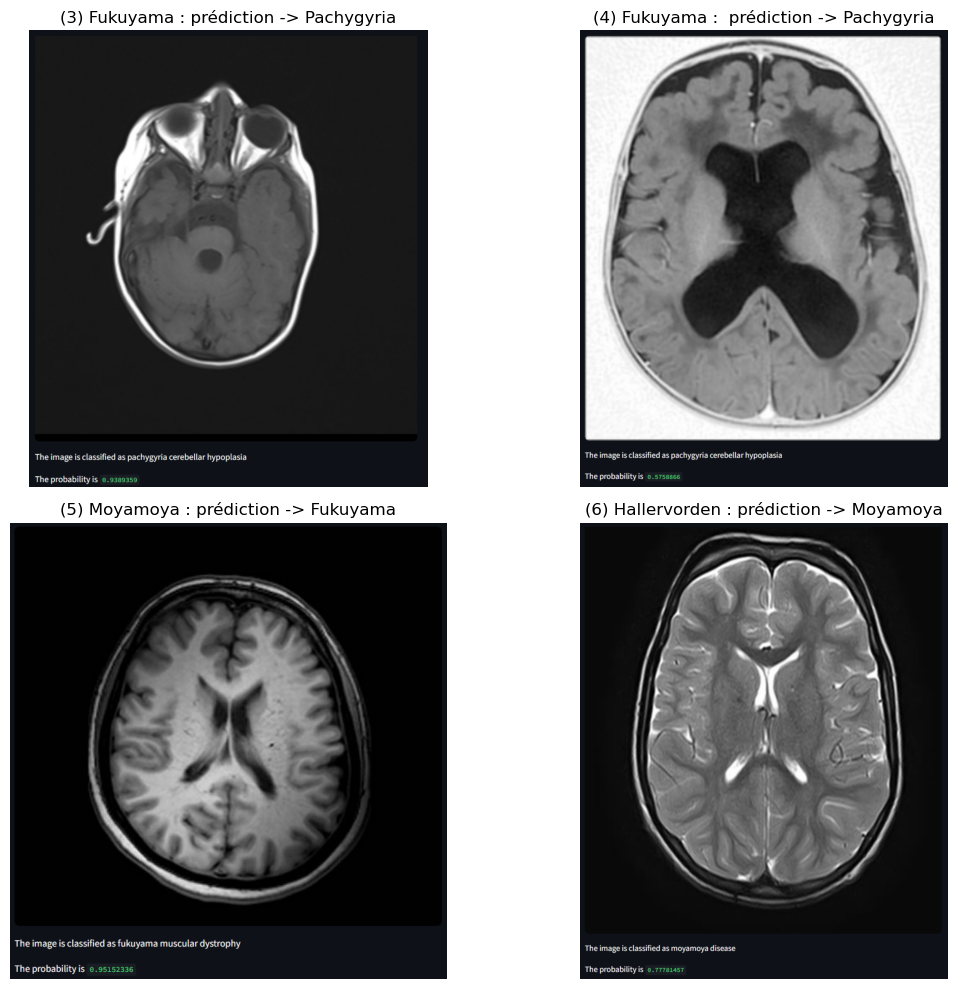

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(mpimg.imread('fukuyama_pas_pachy.png'))
axes[0, 0].set_title('(3) Fukuyama : prédiction -> Pachygyria')
axes[0, 0].axis('off')

axes[0, 1].imshow(mpimg.imread('fukuyama_pas_pachy2.png'))
axes[0, 1].set_title('(4) Fukuyama :  prédiction -> Pachygyria')
axes[0, 1].axis('off')

axes[1, 0].imshow(mpimg.imread('moyamoya_pas_fukuyama.png'))
axes[1, 0].set_title('(5) Moyamoya : prédiction -> Fukuyama')
axes[1, 0].axis('off')

axes[1, 1].imshow(mpimg.imread('hallervorden_pas_moyamoya.png'))
axes[1, 1].set_title('(6) Hallervorden : prédiction -> Moyamoya')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

On voit alors que la classification est mauvaise : la classe prédite ne correspond pas à celle de la maladie. Par ailleurs, on peut voir que le pourcentage est assez élevé pour certaines d’entre elles (>90%). On peut expliquer cette mauvaise classification par le fait que les images choisies ci-dessus ne sont pas similaires aux images que nous avons dans nos bases de données. En effet, lorsque l’on explore le contenu des images fournies, on peut remarquer un point commun entre toutes les images : la segmentation. C’est pour cette raison que par la suite nous avons sélectionnés des images segmentées pour tester notre modèle à partir de l’API.

### 5.2.b. Exemples de bonnes classifications

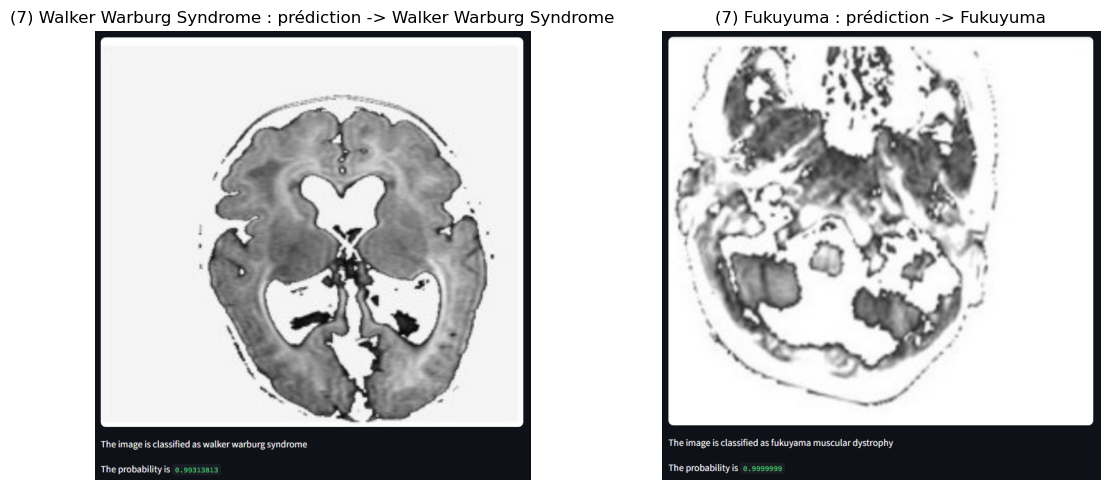

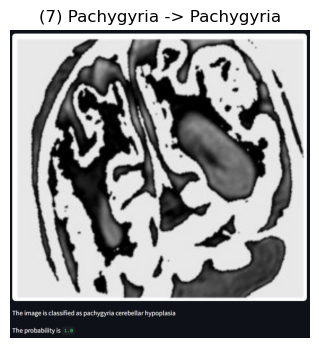

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mpimg.imread('walkeroui.png'))
axes[0].set_title('(7) Walker Warburg Syndrome : prédiction -> Walker Warburg Syndrome')
axes[0].axis('off')

axes[1].imshow(mpimg.imread("fukuyamaoui.png"))
axes[1].set_title('(7) Fukuyuma : prédiction -> Fukuyuma')
axes[1].axis('off')

plt.tight_layout()
plt.show()

img = mpimg.imread('pachyoui.png')

plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title("(7) Pachygyria -> Pachygyria", fontsize=12)
plt.axis('off')
plt.show()

Les images ci-dessous sont des images segmentées représentatives des maladies telles que le syndrome de Walker Warburg, Fukuyama ou encore la Pachygyrie. On peut souligner les résultats positifs que nous obtenons après les avoir données à l’API pour réaliser la classification. En effet, nous avons un pourcentage de précision de 99% voire 100% pour la Pachygyrie. Les résultats obtenus sont alors cohérents avec l’hypothèse avancée précédemment : les images doivent être segmentées pour que la classification soit réussie. Cela s’explique par la forme des images de nos bases de données (train, val et test) qui ont toutes fait l’objet d’une segmentation. De cette manière, le modèle a appris à partir d’un ensemble de données qui reposent toutes sur une même caractéristique (segmentation). Ainsi, toutes images étrangères (qui n’ayant pas subi de segmentation) se voient attribuer une classe qui ne lui appartient pas car le modèle n’a pas été entraîné pour gérer ce genre de données.

# Conclusion

Ce projet avait pour objectif de développer un modèle de Deep Learning capable de diagnostiquer automatiquement cinq maladies neurologiques rares à partir d'images IRM cérébrales : la dystrophie musculaire de Fukuyama, la maladie d'Hallervorden-Spatz, la maladie de Moya Moya, la pachygyrie avec hypoplasie cérébelleuse et le syndrome de Walker-Warburg.

Dans un premier temps, nous avons exploré plusieurs architectures de réseaux de neurones convolutifs afin d'identifier la plus performante. Nous avons ensuite opté pour une approche par transfer learning en utilisant le réseau pré-entraîné VGG16, auquel nous avons appliqué une technique de fine tuning pour l'adapter à notre problématique. Cette approche nous a permis d'atteindre des performances très satisfaisantes sur notre base de test.

La visualisation des filtres du réseau nous a permis de mieux comprendre les caractéristiques extraites par le modèle et ainsi d'interpréter son fonctionnement interne. Enfin, nous avons déployé notre modèle sous forme d'API via Streamlit, ce qui a permis de tester son comportement sur des images extérieures à notre base de données.

Les tests réalisés ont mis en évidence un résultat important : le modèle fonctionne de manière optimale uniquement sur des images segmentées, à l'image des données sur lesquelles il a été entraîné. En effet, les images non segmentées issues d'internet donnent lieu à des classifications erronées, tandis que les images segmentées sont classifiées avec une précision pouvant atteindre 99 à 100%. Cela souligne l'importance de la cohérence entre les données d'entraînement et les données utilisées en production.

En perspective, il serait intéressant d'enrichir la base de données avec des images non segmentées afin de rendre le modèle plus robuste et généralisable à des images cliniques réelles. Une autre piste d'amélioration serait d'intégrer une étape de pré-traitement automatique de segmentation en amont du modèle de classification.

## Bibliographie

[1] S. Hosseini, ‘Bureau d'études Apprentissage Automatique (machine learning)’.

[2] S. Aslam, H. H. Mughal, N. Akram, I. Maqbool, A. Shafi, and Md. A. Haque, ‘An insight to Fukuyama congenital muscular
dystrophy (FCMD): Report of a rare case’, Medical Reports, vol. 3, p. 100028, Feb. 2024, doi: 10.1016/j.hmedic.2023.100028.

[3] R. Thibodeau, ‘Creutzfeldt-Jakob disease | Radiology Case | Radiopaedia.org’, Radiopaedia. Accessed: Apr. 19, 2026. [Online]. Available: https://radiopaedia.org/cases/creutzfeldt-jakob-disease-20

[4] S. P. Ganta, ‘Fukuyama congenital muscular dystrophy | Radiology Case | Radiopaedia.org’, Radiopaedia. Accessed: Apr. 19, 2026. [Online]. Available: https://radiopaedia.org/cases/fukuyama-congenital-muscular-dystrophy

[5] B. D. Muzio, ‘Hemolytic uremic syndrome | Radiology Reference Article | Radiopaedia.org’, Radiopaedia. Accessed: Apr. 19, 2026. [Online]. Available: https://radiopaedia.org/articles/haemolytic-uraemic-syndrome

[6] ‘Keras: Deep Learning for humans’. Accessed: Apr. 19, 2026. [Online]. Available: https://keras.io/

[7] A. Hanzala, M. Sajjad, T. Akter, H. Kaur, and M. S. Rahman, ‘NeuroFusion: A forensic enriched ensemble framework for cerebellum disease classification’, Neuroscience Informatics, vol. 6, no. 1, p. 100251, Mar. 2026, doi: 10.1016/j.neuri.2025.100251.
